# Modelo 2 - Clasificación Binaria: Nivel de Rendimiento del Estudiante

**Pregunta de negocio:** ¿El estudiante tendrá un rendimiento **Alto** o **Bajo**?

**Categorías (binario):**
- **Alto:** punt_global ≥ 300 (antes: Excelente + Bueno)
- **Bajo:** punt_global < 300 (antes: Aceptable + Bajo)

**Usuario final:** Secretaría de Educación de Santander

**Rol:** Ciencia de Datos - Integrante 2

## 1. Instalación de librerías

In [ ]:
!pip install tensorflow scikit-learn mlflow pandas numpy matplotlib seaborn

## 2. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.keras
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)
print('MLflow version:', mlflow.__version__)

TensorFlow version: 2.21.0
MLflow version: 3.12.0


## 3. Carga de datos

In [2]:
# Cambia el path al nombre de tu archivo CSV
df = pd.read_csv('saber11_santander_final.csv')
print('Shape:', df.shape)
df.head()

Shape: (171494, 42)


,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_depto_ubicacion,cole_genero,cole_jornada,...,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20194,TI,SB11201940226736,URBANO,N,A,TÉCNICO/ACADÉMICO,SANTANDER,MIXTO,MAÑANA,...,Si,Si,Si,A2,61.0,64.0,49,59,63,295
1,20194,TI,SB11201940226736,URBANO,N,A,TÉCNICO/ACADÉMICO,SANTANDER,MIXTO,MAÑANA,...,Si,Si,Si,A2,61.0,64.0,49,59,63,295
2,20172,TI,SB11201720104447,URBANO,N,A,TÉCNICO/ACADÉMICO,SANTANDER,MIXTO,TARDE,...,No,No,Si,A-,47.0,59.0,64,59,68,307
3,20172,TI,SB11201720187961,URBANO,N,A,TÉCNICO/ACADÉMICO,SANTANDER,MIXTO,MAÑANA,...,No,Si,Si,A-,44.0,45.0,45,50,46,232
4,20142,CC,SB11201420049509,URBANO,N,A,TÉCNICO/ACADÉMICO,SANTANDER,MIXTO,MAÑANA,...,No,No,Si,A-,45.0,53.0,53,39,50,242


## 4. Creación de la variable objetivo (binaria)

In [3]:
# Clasificación binaria: Alto (>=300) vs Bajo (<300)
def categorizar_binario(p):
    return 'Alto' if p >= 300 else 'Bajo'

df['nivel_rendimiento'] = df['punt_global'].apply(categorizar_binario)

print('Distribución de categorías:')
print(df['nivel_rendimiento'].value_counts())
print('\nPorcentajes:')
print(df['nivel_rendimiento'].value_counts(normalize=True).round(3) * 100)

Distribución de categorías:
nivel_rendimiento
Bajo    124846
Alto     46648
Name: count, dtype: int64

Porcentajes:
nivel_rendimiento
Bajo    72.8
Alto    27.2
Name: proportion, dtype: float64


## 5. Exploración de datos (EDA)

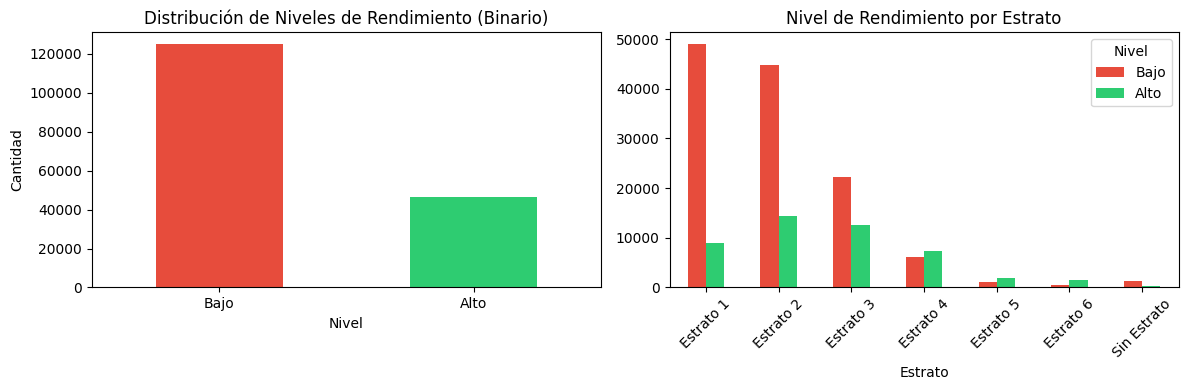

In [4]:
orden = ['Bajo', 'Alto']
colores = ['#e74c3c', '#2ecc71']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
counts = df['nivel_rendimiento'].value_counts()[orden]
counts.plot(kind='bar', color=colores)
plt.title('Distribución de Niveles de Rendimiento (Binario)')
plt.xlabel('Nivel')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
estrato_nivel = df.groupby(['fami_estratovivienda', 'nivel_rendimiento']).size().unstack(fill_value=0)
# Solo mostrar columnas que existan
cols_presentes = [c for c in orden if c in estrato_nivel.columns]
estrato_nivel[cols_presentes].plot(kind='bar', color=colores[:len(cols_presentes)], ax=plt.gca())
plt.title('Nivel de Rendimiento por Estrato')
plt.xlabel('Estrato')
plt.xticks(rotation=45)
plt.legend(title='Nivel')

plt.tight_layout()
plt.savefig('eda_clasificacion_binaria.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Preprocesamiento

In [5]:
features = [
    'cole_area_ubicacion', 'cole_calendario', 'cole_caracter',
    'cole_jornada', 'cole_naturaleza', 'cole_mcpio_ubicacion',
    'estu_genero', 'estu_privado_libertad',
    'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre',
    'fami_estratovivienda', 'fami_personashogar',
    'fami_tieneautomovil', 'fami_tienecomputador',
    'fami_tieneinternet', 'fami_tienelavadora'
]

target = 'nivel_rendimiento'
clases = ['Bajo', 'Alto']  # 0 = Bajo, 1 = Alto

df_model = df[features + [target]].dropna().copy()

# Codificar features categóricos
le_dict = {}
for col in features:
    if df_model[col].dtype == object:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
joblib.dump(le_dict, 'encoders_clasificacion_binaria.pkl')

# Codificar target: Bajo=0, Alto=1
le_target = LabelEncoder()
le_target.fit(clases)
y = le_target.transform(df_model[target])  # Bajo->0, Alto->1
joblib.dump(le_target, 'encoder_target_clasificacion_binaria.pkl')

print('Clases codificadas:', list(zip(le_target.classes_, le_target.transform(le_target.classes_))))

X = df_model[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, 'scaler_clasificacion_binaria.pkl')

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Balance en train - Bajo:', (y_train == 0).sum(), '| Alto:', (y_train == 1).sum())

Clases codificadas: [(np.str_('Alto'), np.int64(0)), (np.str_('Bajo'), np.int64(1))]
Train: (137195, 17) | Test: (34299, 17)
Balance en train - Bajo: 37318 | Alto: 99877


## 7. Modelamiento con Red Neuronal (Binaria)

In [6]:
def build_model_binario(hidden_layers, neurons, dropout_rate, learning_rate):
    """
    Modelo de clasificación BINARIA.
    Salida: 1 neurona con activación sigmoid -> probabilidad de clase 'Alto'.
    Loss: binary_crossentropy
    """
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    # Capa de salida binaria: 1 neurona + sigmoid
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [8]:
import os
os.chdir(r"C:\Users\Nicolas Pinilla\Desktop\IND\Analitica_computancional\Proyecto 2")
print("Directorio actual:", os.getcwd())

Directorio actual: C:\Users\Nicolas Pinilla\Desktop\IND\Analitica_computancional\Proyecto 2


In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Calcular pesos inversamente proporcionales a la frecuencia
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Pesos de clase:", class_weight_dict)

Pesos de clase: {0: np.float64(1.8381880057880915), 1: np.float64(0.6868197883396577)}


In [19]:
mlflow.set_tracking_uri("mlruns")  # carpeta relativa, sin rutas absolutas
mlflow.set_experiment('clasificacion_binaria_rendimiento')
# Reemplaza los experimentos por esta configuración más potente
experimentos = [
    {'hidden_layers': 3, 'neurons': 128, 'dropout': 0.3, 'lr': 0.001},
    {'hidden_layers': 4, 'neurons': 256, 'dropout': 0.25, 'lr': 0.0005},
    {'hidden_layers': 5, 'neurons': 512, 'dropout': 0.3, 'lr': 0.0003},
]

best_acc = 0
best_model = None
best_history = None

for exp in experimentos:
    with mlflow.start_run(run_name=f"binario_hl{exp['hidden_layers']}_n{exp['neurons']}"):
        mlflow.log_params(exp)

        model = build_model_binario(
            exp['hidden_layers'], exp['neurons'],
            exp['dropout'], exp['lr']
        )

        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=100,        # antes 50
            batch_size=128,    # antes 256, lotes más pequeños = mejor aprendizaje
            verbose=0,
            class_weight=class_weight_dict,
            callbacks=[keras.callbacks.EarlyStopping(
                patience=10,   # antes 5, más paciencia
                restore_best_weights=True
            )]
        )

        # Predicciones binarias: umbral 0.5
        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        mlflow.log_metric('accuracy', acc)
        mlflow.log_metric('roc_auc', auc)
        mlflow.keras.log_model(model, 'model')

        print(f"hl={exp['hidden_layers']} n={exp['neurons']} → Accuracy={acc:.3f} | AUC={auc:.3f}")

        if acc > best_acc:
            best_acc = acc
            best_model = model
            best_history = history

print(f'\nMejor Accuracy: {best_acc:.3f}')

1072/1072 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


2026/05/25 12:55:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 12:55:33 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


hl=3 n=128 → Accuracy=0.716 | AUC=0.779
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


2026/05/25 12:59:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 12:59:53 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


hl=4 n=256 → Accuracy=0.701 | AUC=0.782
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


2026/05/25 13:06:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 13:06:04 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


hl=5 n=512 → Accuracy=0.713 | AUC=0.778

Mejor Accuracy: 0.716


## 8. Evaluación del mejor modelo

In [ ]:
# Predicciones finales
y_prob_best = best_model.predict(X_test).ravel()
y_pred_best = (y_prob_best >= 0.5).astype(int)

# NOTA: LabelEncoder codificó alfabéticamente → Alto=0, Bajo=1
# target_names debe seguir ese mismo orden: índice 0 → 'Alto', índice 1 → 'Bajo'
print('=== Reporte de Clasificación Binaria ===')
print(classification_report(y_test, y_pred_best, target_names=['Alto', 'Bajo']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_best):.4f}')
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)

# Umbral óptimo por criterio Youden J
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"\nUmbral óptimo encontrado: {best_threshold:.3f}")

# Predicción con umbral óptimo
y_pred_optimo = (y_prob_best >= best_threshold).astype(int)

print('=== Reporte con umbral óptimo ===')
print(classification_report(y_test, y_pred_optimo, target_names=['Alto', 'Bajo']))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de confusión — filas/cols ordenadas por índice: 0=Alto, 1=Bajo
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Alto', 'Bajo'],
            yticklabels=['Alto', 'Bajo'], ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_val = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC')
axes[1].legend(loc='lower right')

# 3. Histograma: y_test==0 → Alto (verde), y_test==1 → Bajo (rojo)
axes[2].hist(y_prob_best[y_test == 0], bins=30, alpha=0.6,
             color='#2ecc71', label='Alto (real)')
axes[2].hist(y_prob_best[y_test == 1], bins=30, alpha=0.6,
             color='#e74c3c', label='Bajo (real)')
axes[2].axvline(best_threshold, color='black', linestyle='--',
                label=f'Umbral óptimo {best_threshold:.2f}')
axes[2].set_xlabel('Probabilidad predicha (clase Bajo)')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución de Probabilidades')
axes[2].legend()

plt.tight_layout()
plt.savefig('eval_clasificacion_binaria.png', dpi=150, bbox_inches='tight')
plt.show()

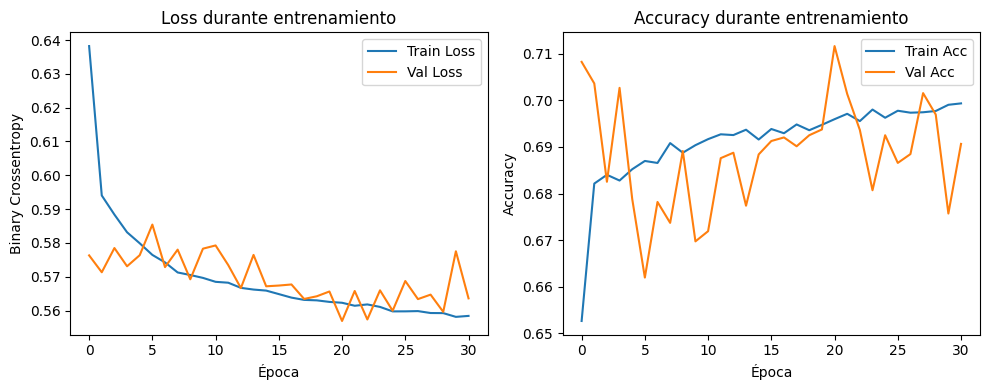

In [21]:
# Curva de aprendizaje
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Val Loss')
plt.title('Loss durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history.history['accuracy'], label='Train Acc')
plt.plot(best_history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('curvas_aprendizaje_binaria.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Guardar modelo

In [22]:
best_model.save('modelo_clasificacion_binaria.h5')
print('Modelo guardado:  modelo_clasificacion_binaria.h5')
print('Encoders:         encoders_clasificacion_binaria.pkl')
print('Encoder target:   encoder_target_clasificacion_binaria.pkl')
print('Scaler:           scaler_clasificacion_binaria.pkl')
print()
print('=== Uso del modelo para predicción ===')
print('  prob = model.predict(X_nuevo)  # valor entre 0 y 1')
print('  pred = (prob >= 0.5).astype(int)  # 0=Bajo, 1=Alto')

Modelo guardado:  modelo_clasificacion_binaria.h5
Encoders:         encoders_clasificacion_binaria.pkl
Encoder target:   encoder_target_clasificacion_binaria.pkl
Scaler:           scaler_clasificacion_binaria.pkl

=== Uso del modelo para predicción ===
  prob = model.predict(X_nuevo)  # valor entre 0 y 1
  pred = (prob >= 0.5).astype(int)  # 0=Bajo, 1=Alto
